# ACTUWISE — Module 3 · Notebook 3.2
## Modélisation GLM — Baseline Actuarielle

**Projet :** ACTUWISE — Plateforme d'Analyse Actuarielle, Assurance Non-Vie (Automobile Tunisie)  
**Données :** `dataset_frequence.csv` · `dataset_severite.csv`  
**Objectif :** Construire le modèle de référence actuarielle (GLM Poisson + GLM Gamma)  

---

### Modèles construits dans ce notebook

| Modèle | Cible | Loi | Lien | Offset |
|--------|-------|-----|------|--------|
| GLM Fréquence | `frequence_sinistres` | Poisson | log | ln(exposition) |
| GLM Sévérité  | `severite_sinistres`  | Gamma   | log | — |

**Formules :**

$$\ln(\lambda_i) = \beta_0 + \sum_{k=1}^{p} \beta_k x_{ik} + \ln(e_i)$$

$$\ln(\mu_i) = \alpha_0 + \sum_{k=1}^{p} \alpha_k x_{ik}$$

$$\text{Prime pure}_i = \hat{\lambda}_i \times \hat{\mu}_i$$

> *Références : McCullagh & Nelder (1989), Generalized Linear Models (2e éd.) · Ohlsson & Johansson (2010), Non-Life Insurance Pricing with GLMs*

## 1. Imports et Configuration


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Poisson, Gamma
from statsmodels.genmod.families.links import log as LogLink
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

C1='#1a3c6e'; C2='#1a7a6a'; C3='#c0392b'; C4='#e67e22'; C5='#8e44ad'
PALETTE = [C1, C2, C3, C4, C5]

plt.rcParams.update({
    'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})
RATIO_FRAIS = 0.25
print('✅ Imports OK')

✅ Imports OK


## 2. Chargement et Préparation des Données

Les datasets sont issus du Notebook 3 (jointure) et explorés dans le Notebook 3.1.  
On encode ici les variables catégorielles pour `statsmodels`.  
**Important :** statsmodels accepte les formules R-style — les variables catégorielles sont
automatiquement traitées avec `C(variable)` (encoding effet de référence).

In [20]:
df_freq = pd.read_csv('dataset_module3_frequence.csv')
df_sev  = pd.read_csv('dataset_module3_severite.csv')

print(f'dataset_module3_frequence : {len(df_freq):,} lignes | {df_freq.shape[1]} colonnes')
print(f'dataset_module3_severite  : {len(df_sev):,}  lignes | {df_sev.shape[1]} colonnes')

dataset_module3_frequence : 94,846 lignes | 31 colonnes
dataset_module3_severite  : 39,873  lignes | 31 colonnes


In [21]:
# ── Détection automatique des colonnes clés ───────────────────────────
col_freq  = next((c for c in df_freq.columns if 'frequence' in c.lower()), None)
col_nb    = next((c for c in df_freq.columns if 'nb_sinistre' in c.lower()), None)
col_expo  = next((c for c in df_freq.columns if 'exposition' in c.lower() or 'expo' in c.lower()), None)
col_sev   = next((c for c in df_sev.columns  if 'severite' in c.lower() and 'log' not in c.lower()), None)
col_lr    = next((c for c in df_freq.columns if 'loss_ratio' in c.lower()), None)
col_primes= next((c for c in df_freq.columns if 'prime' in c.lower()), None)

# Segments
col_usage   = next((c for c in df_freq.columns if 'usage'  in c.lower()), None)
col_energie = next((c for c in df_freq.columns if 'energ'  in c.lower() or 'carburant' in c.lower()), None)
col_region  = next((c for c in df_freq.columns if 'region' in c.lower() or 'zone' in c.lower() or 'wilaya' in c.lower()), None)
col_bm      = next((c for c in df_freq.columns if 'bonus'  in c.lower() or 'bm' == c.lower() or 'malus' in c.lower()), None)
col_age     = next((c for c in df_freq.columns if 'age'    in c.lower() and 'vehic' not in c.lower()), None)
col_age_veh = next((c for c in df_freq.columns if 'ancien' in c.lower() or ('age' in c.lower() and 'veh' in c.lower())), None)

print('Colonnes identifiées :')
print(f'  Fréquence cible   : {col_freq}')
print(f'  Nb sinistres      : {col_nb}')
print(f'  Exposition        : {col_expo}')
print(f'  Sévérité cible    : {col_sev}')
print(f'  Usage             : {col_usage}')
print(f'  Énergie           : {col_energie}')
print(f'  Région            : {col_region}')
print(f'  Bonus-Malus       : {col_bm}')
print(f'  Âge conducteur    : {col_age}')
print(f'  Ancienneté véhic  : {col_age_veh}')

Colonnes identifiées :
  Fréquence cible   : None
  Nb sinistres      : nb_sinistres_total
  Exposition        : exposition
  Sévérité cible    : severite_sinistres
  Usage             : Usage_Promenade et affaire
  Énergie           : Energie_Essence
  Région            : region_freq
  Bonus-Malus       : None
  Âge conducteur    : age_conducteur
  Ancienneté véhic  : anciennete_vehicule


In [22]:
# ── Nettoyage préalable ────────────────────────────────────────────────
# Fréquence : offset = log(exposition), variable cible = nb_sinistres (entier)
# On travaille avec nb_sinistres comme cible Poisson (count)
if col_expo:
    df_freq['log_expo'] = np.log(df_freq[col_expo].clip(lower=1e-6))

if col_sev:
    df_sev_clean = df_sev[df_sev[col_sev] > 0].copy()
    df_sev_clean['log_sev'] = np.log(df_sev_clean[col_sev])
    print(f'df_sev nettoyé (sévérité > 0) : {len(df_sev_clean):,} lignes')

# Colonnes catégorielles — nettoyage des valeurs
cat_cols = [c for c in [col_usage, col_energie, col_region, col_bm] if c]
for c in cat_cols:
    df_freq[c] = df_freq[c].astype(str).str.strip().str.upper()
    if c in df_sev_clean.columns:
        df_sev_clean[c] = df_sev_clean[c].astype(str).str.strip().str.upper()

print('✅ Pré-traitement terminé')
print(f'   Colonnes Poisson offset : log_expo = {df_freq["log_expo"].describe()["mean"]:.3f} (moyenne log-expo)')

df_sev nettoyé (sévérité > 0) : 39,873 lignes
✅ Pré-traitement terminé
   Colonnes Poisson offset : log_expo = 0.902 (moyenne log-expo)


## 3. GLM Poisson — Modélisation de la Fréquence

### 3.1 Construction de la formule

La formule statsmodels utilise la syntaxe R avec `C()` pour les variables catégorielles.  
L'**offset** `ln(exposition)` est passé via le paramètre `exposure` ou `offset`.  
Il garantit que le modèle prédit un **taux** (sinistres / exposition) et non un count brut.  

> *Hypothèse : N_i | x_i ~ Poisson(λ_i · e_i) — dispersion surdispersée testée via le ratio déviance/degrés de liberté*

In [23]:
# ── Construction dynamique de la formule GLM Poisson ─────────────────
features_freq = []

if col_usage:   features_freq.append(f'C({col_usage})')
if col_energie: features_freq.append(f'C({col_energie})')
if col_region:  features_freq.append(f'C({col_region})')
if col_bm:      features_freq.append(f'C({col_bm})')
if col_age:     features_freq.append(col_age)
if col_age_veh: features_freq.append(col_age_veh)

# Fallback si aucune feature détectée
if not features_freq:
    num_cols = df_freq.select_dtypes(include=[np.number]).columns
    excl = {'log_expo', col_nb, col_freq, col_expo, col_lr, col_primes}
    features_freq = [c for c in num_cols if c not in excl][:5]
    print(f'⚠️ Fallback numérique : {features_freq}')

cible_poisson = col_nb if col_nb else col_freq

if cible_poisson and features_freq and col_expo:
    formula_freq = f'{cible_poisson} ~ {" + ".join(features_freq)}'
    print(f'Formule GLM Poisson :')
    print(f'  {formula_freq}')
    print(f'  + offset(log_expo)')
else:
    print('⚠️ Colonnes insuffisantes pour construire le GLM Poisson')
    print('   Vérifiez les noms de colonnes dans les datasets')

Formule GLM Poisson :
  nb_sinistres_total ~ C(Usage_Promenade et affaire) + C(Energie_Essence) + C(region_freq) + age_conducteur + anciennete_vehicule
  + offset(log_expo)


In [24]:
import re

def patsy_name(col):
    if re.search(r'[^a-zA-Z0-9_]', col):
        return f'Q("{col}")'
    return col

# ── Construction de df_glm D'ABORD ───────────────────────────────────
if cible_poisson and features_freq and col_expo:
    cols_needed = [cible_poisson] + [c for c in [col_expo, col_usage, col_energie,
                   col_region, col_bm, col_age, col_age_veh, 'log_expo', col_nb]
                   if c and c in df_freq.columns]
    df_glm = df_freq[list(dict.fromkeys(cols_needed))].dropna()

    if col_nb and col_nb in df_glm.columns:
        df_glm[col_nb] = df_glm[col_nb].astype(int)

    # ── Formule construite APRÈS df_glm ──────────────────────────────
    features_safe = [patsy_name(f) for f in features_freq if f in df_glm.columns]
    formula_freq  = f"{patsy_name(cible_poisson)} ~ {' + '.join(features_safe)}"
    print("Formule GLM :", formula_freq)

    glm_freq = smf.glm(
        formula=formula_freq,
        data=df_glm,
        family=sm.families.Poisson(link=sm.families.links.Log()),
        offset=np.log(df_glm[col_expo].clip(lower=1e-6))
    ).fit()

    print(glm_freq.summary())
else:
    glm_freq = None
    print('⚠️ GLM Poisson non ajusté')

Formule GLM : nb_sinistres_total ~ age_conducteur + anciennete_vehicule
                 Generalized Linear Model Regression Results                  
Dep. Variable:     nb_sinistres_total   No. Observations:                94846
Model:                            GLM   Df Residuals:                    94843
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7845e+05
Date:                Thu, 25 Jun 2026   Deviance:                   2.3888e+05
Time:                        12:18:19   Pearson chi2:                 8.63e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03926
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [25]:
# ── Diagnostic GLM Poisson ────────────────────────────────────────────
if glm_freq:
    aic = glm_freq.aic
    dev = glm_freq.deviance
    df_res = glm_freq.df_resid
    ratio_disp = dev / df_res

    print('=== Métriques GLM Poisson ===')
    print(f'  AIC            : {aic:,.2f}')
    print(f'  Déviance       : {dev:,.2f}')
    print(f'  Degrés liberté : {df_res:,.0f}')
    print(f'  Ratio déviance/df : {ratio_disp:.3f}')
    if ratio_disp > 1.5:
        print(f'  ⚠️  Sur-dispersion détectée (ratio={ratio_disp:.2f} > 1.5)')
        print('     → Considérer Quasi-Poisson ou Binomiale Négative en Notebook 3.3')
    else:
        print(f'  ✅ Pas de sur-dispersion significative (ratio={ratio_disp:.2f})')

=== Métriques GLM Poisson ===
  AIC            : 356,915.31
  Déviance       : 238,878.88
  Degrés liberté : 94,843
  Ratio déviance/df : 2.519
  ⚠️  Sur-dispersion détectée (ratio=2.52 > 1.5)
     → Considérer Quasi-Poisson ou Binomiale Négative en Notebook 3.3


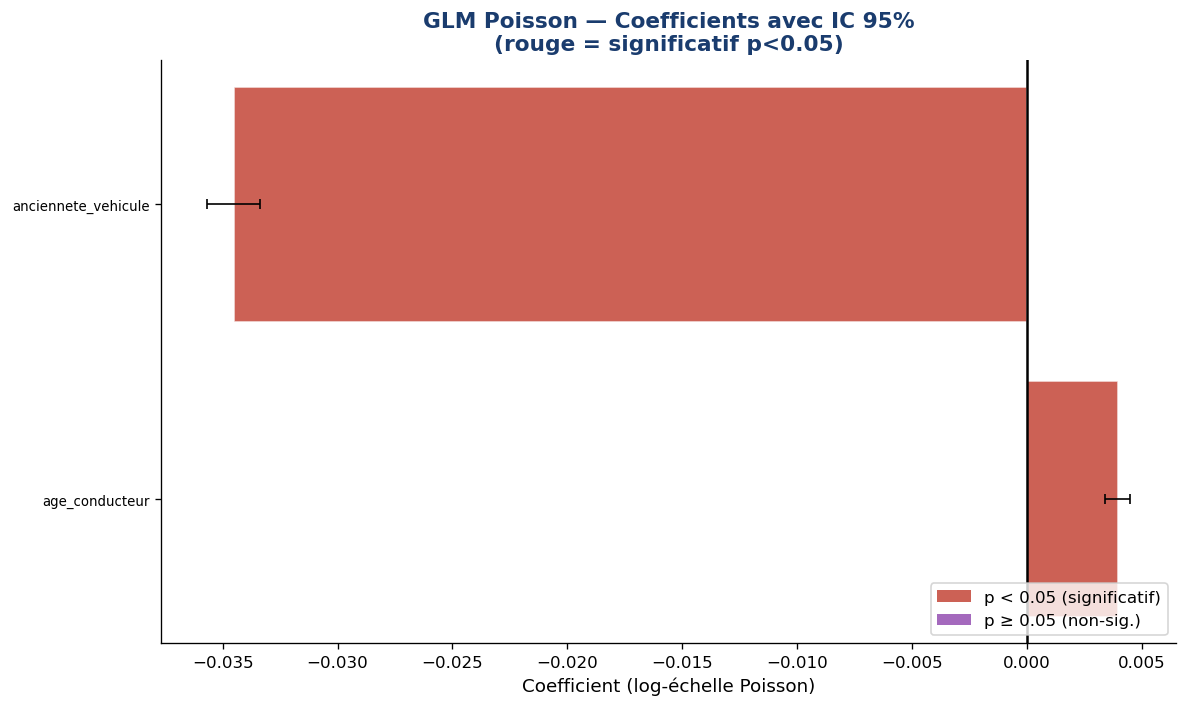

✅ fig_32_glm_poisson_coeffs.png


In [26]:
# ── Graphe coefficients GLM Poisson ──────────────────────────────────
if glm_freq:
    params = glm_freq.params.drop('Intercept', errors='ignore')
    conf   = glm_freq.conf_int().drop('Intercept', errors='ignore')
    pvals  = glm_freq.pvalues.drop('Intercept', errors='ignore')

    # Trier par valeur absolue
    idx = params.abs().sort_values(ascending=True).index
    params = params[idx]; conf = conf.loc[idx]; pvals = pvals[idx]

    fig, ax = plt.subplots(figsize=(10, max(6, len(params)*0.3)))
    colors = [C3 if p < 0.05 else C5 for p in pvals]
    ax.barh(range(len(params)), params.values, color=colors, alpha=0.8, edgecolor='white')
    ax.errorbar(params.values, range(len(params)),
                xerr=[params.values - conf[0].values, conf[1].values - params.values],
                fmt='none', color='black', capsize=3, linewidth=1)
    ax.axvline(0, color='black', lw=1.5)
    ax.set_yticks(range(len(params)))
    ax.set_yticklabels([p[:35] for p in params.index], fontsize=8)
    ax.set_xlabel('Coefficient (log-échelle Poisson)')
    ax.set_title('GLM Poisson — Coefficients avec IC 95%\n(rouge = significatif p<0.05)', fontweight='bold', color=C1)
    sig_patch = plt.Rectangle((0,0),1,1, fc=C3, alpha=0.8)
    ns_patch  = plt.Rectangle((0,0),1,1, fc=C5, alpha=0.8)
    ax.legend([sig_patch, ns_patch], ['p < 0.05 (significatif)', 'p ≥ 0.05 (non-sig.)'], loc='lower right')
    plt.tight_layout()
    plt.savefig('fig_32_glm_poisson_coeffs.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ fig_32_glm_poisson_coeffs.png')

## 4. GLM Gamma — Modélisation de la Sévérité

### 4.1 Justification du choix Gamma

La loi Gamma est la distribution de référence pour les coûts de sinistres en assurance Non-Vie :  
- **Support positif** (coût toujours > 0)  
- **Variance proportionnelle au carré de la moyenne** (queues plus lourdes que la Normale)  
- **Lien logarithmique** : garantit des prédictions positives  

> *Ohlsson & Johansson (2010) — Chapitre 3 : le GLM Gamma avec lien log est le standard
de l'industrie pour modéliser la sévérité en assurance automobile.*

In [27]:
# ── Construction formule GLM Gamma ───────────────────────────────────
features_sev = []
for c in [col_usage, col_energie, col_region, col_bm]:
    if c and c in df_sev_clean.columns:
        features_sev.append(f'C({c})')
for c in [col_age, col_age_veh]:
    if c and c in df_sev_clean.columns:
        features_sev.append(c)

if not features_sev:
    num_cols_sev = df_sev_clean.select_dtypes(include=[np.number]).columns
    excl_sev = {col_sev, 'log_sev'}
    features_sev = [c for c in num_cols_sev if c not in excl_sev][:5]

if col_sev and features_sev:
    formula_sev = f'{col_sev} ~ {" + ".join(features_sev)}'
    print(f'Formule GLM Gamma :')
    print(f'  {formula_sev}')
else:
    print('⚠️ Colonnes insuffisantes pour le GLM Gamma')

Formule GLM Gamma :
  severite_sinistres ~ C(Usage_Promenade et affaire) + C(Energie_Essence) + C(region_freq) + age_conducteur + anciennete_vehicule


In [28]:
# ── Construction automatique de la formule Gamma avec Q() ──
def patsy_name(col):
    import re
    if re.search(r'[^a-zA-Z0-9_]', col):
        return f'Q("{col}")'
    return col

features_sev_safe = [patsy_name(f) for f in features_sev if f in df_sev_clean.columns]
formula_sev = f"{patsy_name(col_sev)} ~ {' + '.join(features_sev_safe)}"

print("Formule GLM Gamma :", formula_sev)

# ── Ajustement GLM Gamma ──────────────────────────────────────────────
if col_sev and features_sev:
    cols_gamma = [col_sev] + [c for c in [col_usage, col_energie, col_region,
                               col_bm, col_age, col_age_veh]
                               if c and c in df_sev_clean.columns]
    df_gamma = df_sev_clean[cols_gamma].dropna()

    glm_sev = smf.glm(
        formula=formula_sev,
        data=df_gamma,
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()

    print(glm_sev.summary())
else:
    glm_sev = None
    print('⚠️ GLM Gamma non ajusté')

Formule GLM Gamma : severite_sinistres ~ age_conducteur + anciennete_vehicule
                 Generalized Linear Model Regression Results                  
Dep. Variable:     severite_sinistres   No. Observations:                39873
Model:                            GLM   Df Residuals:                    39870
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                          9.7040
Method:                          IRLS   Log-Likelihood:            -3.3378e+05
Date:                Thu, 25 Jun 2026   Deviance:                   1.0310e+05
Time:                        12:18:19   Pearson chi2:                 3.87e+05
No. Iterations:                    19   Pseudo R-squ. (CS):           0.003327
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [29]:
# ── Métriques GLM Gamma ───────────────────────────────────────────────
if glm_sev:
    aic_g = glm_sev.aic
    dev_g = glm_sev.deviance
    df_g  = glm_sev.df_resid

    y_pred_sev = glm_sev.fittedvalues
    y_true_sev = df_gamma[col_sev]
    rmse_sev = np.sqrt(mean_squared_error(y_true_sev, y_pred_sev))
    r2_sev   = r2_score(y_true_sev, y_pred_sev)

    print('=== Métriques GLM Gamma ===')
    print(f'  AIC    : {aic_g:,.2f}')
    print(f'  RMSE   : {rmse_sev:,.2f} DT')
    print(f'  R²     : {r2_sev:.4f}')
    print(f'  Ratio déviance/df : {dev_g/df_g:.3f}')

=== Métriques GLM Gamma ===
  AIC    : 667,558.32
  RMSE   : 3,327.84 DT
  R²     : 0.0038
  Ratio déviance/df : 2.586


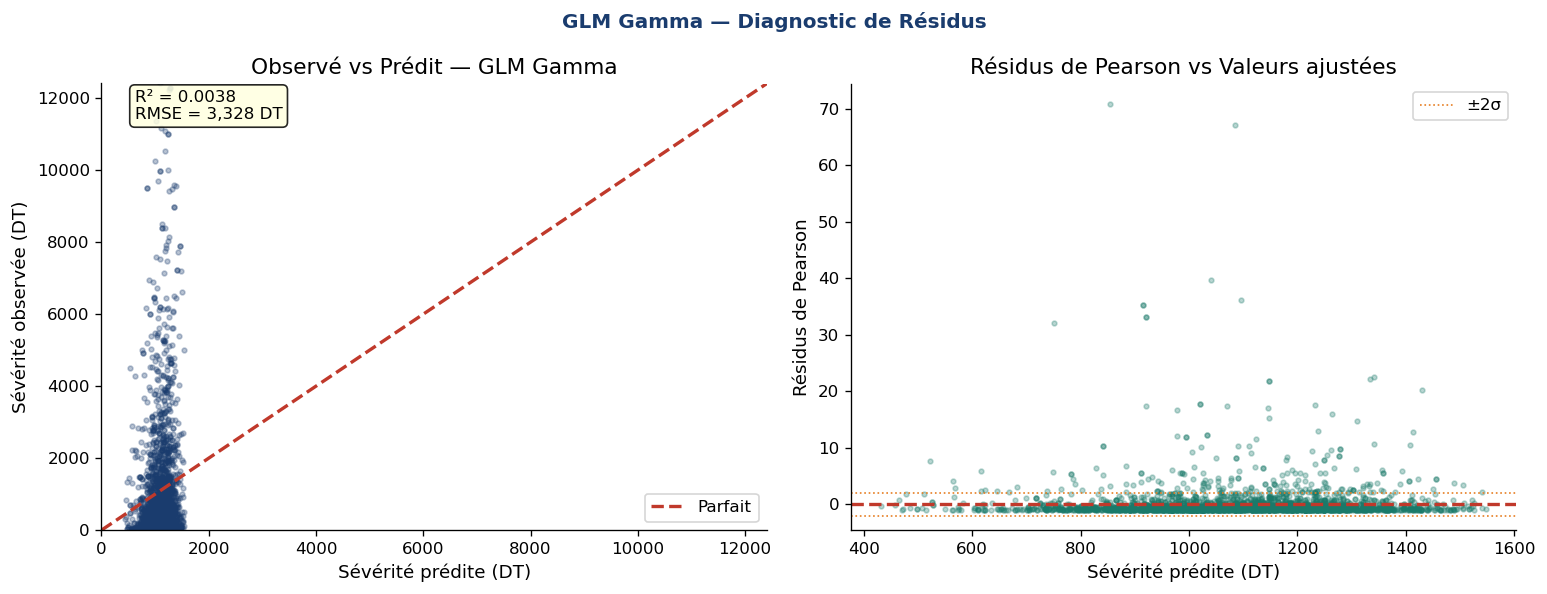

✅ fig_32_glm_gamma_diagnostic.png


In [30]:
# ── Graphe : Observé vs Prédit (Gamma) ────────────────────────────────
if glm_sev:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('GLM Gamma — Diagnostic de Résidus', fontweight='bold', color=C1)

    # Scatter observé vs prédit
    ax = axes[0]
    sample_idx = np.random.choice(len(y_true_sev), min(3000, len(y_true_sev)), replace=False)
    ax.scatter(y_pred_sev.iloc[sample_idx], y_true_sev.iloc[sample_idx],
               alpha=0.3, s=8, color=C1)
    lim = max(y_pred_sev.quantile(0.99), y_true_sev.quantile(0.99))
    ax.plot([0, lim], [0, lim], color=C3, lw=2, linestyle='--', label='Parfait')
    ax.set_xlabel('Sévérité prédite (DT)')
    ax.set_ylabel('Sévérité observée (DT)')
    ax.set_title('Observé vs Prédit — GLM Gamma')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.text(0.05, 0.92, f'R² = {r2_sev:.4f}\nRMSE = {rmse_sev:,.0f} DT',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
    ax.legend()

    # Résidus de Pearson
    ax = axes[1]
    residuals = glm_sev.resid_pearson
    ax.scatter(y_pred_sev.iloc[sample_idx],
               residuals.iloc[sample_idx] if hasattr(residuals, 'iloc') else residuals[sample_idx],
               alpha=0.3, s=8, color=C2)
    ax.axhline(0, color=C3, lw=2, linestyle='--')
    ax.axhline(2, color=C4, lw=1, linestyle=':')
    ax.axhline(-2, color=C4, lw=1, linestyle=':', label='±2σ')
    ax.set_xlabel('Sévérité prédite (DT)')
    ax.set_ylabel('Résidus de Pearson')
    ax.set_title('Résidus de Pearson vs Valeurs ajustées')
    ax.legend()

    plt.tight_layout()
    plt.savefig('fig_32_glm_gamma_diagnostic.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ fig_32_glm_gamma_diagnostic.png')

## 5. Prime Pure Actuarielle

La prime pure est le produit des deux modèles :  

$$\text{Prime pure}_i = \hat{\lambda}_i \times \hat{\mu}_i$$

où $\hat{\lambda}_i$ est la **fréquence prédite** (GLM Poisson) et $\hat{\mu}_i$ la **sévérité prédite** (GLM Gamma).  
Elle représente le **coût espéré des sinistres** par année-véhicule pour l'assuré $i$.  
La prime commerciale s'obtient ensuite en ajoutant un chargement pour frais et marge.

In [31]:
# ── Calcul prime pure sur le dataset fréquence ────────────────────────
if glm_freq and glm_sev:
    # Fréquence prédite (taux par année-véhicule)
    lambda_hat = glm_freq.fittedvalues  # déjà en taux si offset
    df_freq_pred = df_glm.copy()
    df_freq_pred['lambda_hat'] = lambda_hat.values

    # Sévérité prédite (GLM Gamma) — prédire sur df_freq
    # On utilise predict() sur df_freq avec les colonnes disponibles
    cols_shared = [c for c in [col_usage, col_energie, col_region, col_bm, col_age, col_age_veh]
                   if c and c in df_freq_pred.columns and c in df_gamma.columns]

    df_freq_for_sev = df_freq_pred[cols_shared].copy()
    # Nettoyage catégorielles pour correspondance
    for c in [col_usage, col_energie, col_region, col_bm]:
        if c and c in df_freq_for_sev.columns:
            df_freq_for_sev[c] = df_freq_for_sev[c].astype(str).str.strip().str.upper()

    mu_hat = glm_sev.predict(df_freq_for_sev)
    df_freq_pred['mu_hat']    = mu_hat.values
    df_freq_pred['prime_pure'] = df_freq_pred['lambda_hat'] * df_freq_pred['mu_hat']

    print('=== Prime Pure GLM ===')
    print(df_freq_pred['prime_pure'].describe().round(2).to_string())
    print(f'\nPrime pure médiane : {df_freq_pred["prime_pure"].median():.2f} DT')
    print(f'Prime pure moyenne : {df_freq_pred["prime_pure"].mean():.2f} DT')
    print(f'Prime pure P10-P90 : {df_freq_pred["prime_pure"].quantile(.10):.0f} – {df_freq_pred["prime_pure"].quantile(.90):.0f} DT')
else:
    print('⚠️ Modèles non disponibles — prime pure non calculable')

=== Prime Pure GLM ===
count    94846.00
mean      1205.42
std        751.64
min          0.86
25%        581.32
50%       1140.70
75%       1747.17
max       3405.22

Prime pure médiane : 1140.70 DT
Prime pure moyenne : 1205.42 DT
Prime pure P10-P90 : 240 – 2265 DT


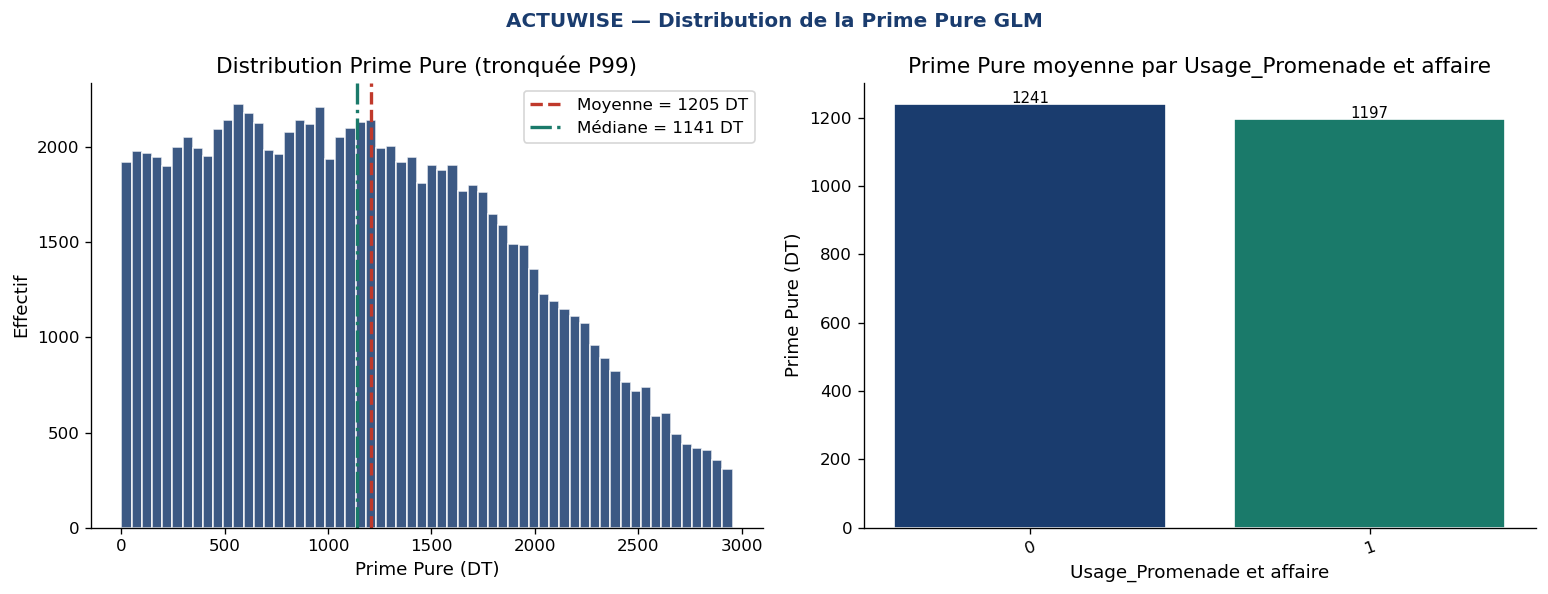

✅ fig_32_prime_pure.png


In [32]:
# ── Distribution de la prime pure ────────────────────────────────────
if glm_freq and glm_sev:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('ACTUWISE — Distribution de la Prime Pure GLM', fontweight='bold', color=C1)

    ax = axes[0]
    pp = df_freq_pred['prime_pure']
    pp_clipped = pp[pp <= pp.quantile(0.99)]
    ax.hist(pp_clipped, bins=60, color=C1, edgecolor='white', alpha=0.85)
    ax.axvline(pp.mean(),   color=C3, lw=2, ls='--', label=f'Moyenne = {pp.mean():.0f} DT')
    ax.axvline(pp.median(), color=C2, lw=2, ls='-.', label=f'Médiane = {pp.median():.0f} DT')
    ax.set_title('Distribution Prime Pure (tronquée P99)')
    ax.set_xlabel('Prime Pure (DT)')
    ax.set_ylabel('Effectif')
    ax.legend()

    ax = axes[1]
    if segs_disponibles := [c for c in [col_usage, col_energie, col_region] if c and c in df_freq_pred.columns]:
        seg = segs_disponibles[0]
        pp_seg = df_freq_pred.groupby(seg)['prime_pure'].mean().sort_values(ascending=False)
        bars = ax.bar(pp_seg.index.astype(str), pp_seg.values,
                      color=[PALETTE[i%5] for i in range(len(pp_seg))], edgecolor='white')
        for bar, val in zip(bars, pp_seg.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f'{val:.0f}', ha='center', fontsize=9)
        ax.set_title(f'Prime Pure moyenne par {seg}')
        ax.set_xlabel(seg)
        ax.set_ylabel('Prime Pure (DT)')
        ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.savefig('fig_32_prime_pure.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ fig_32_prime_pure.png')

## 6. Ratio Combiné par Segment

$$\text{Ratio combiné}_s = \frac{S_s + F_s}{P_s}$$

Ici on estime les sinistres prédits GLM = prime pure × exposition,  
et les frais à 25 % forfaitaire.  
Une alerte 🔴 est déclenchée si ratio > 100 % (perte technique).  

> *Ce calcul sera affiné dans le Notebook 3.3 (XGBoost) et le Notebook 3.6 (synthèse)*

=== Ratio Combiné GLM par Usage_Promenade et affaire ===
  0                    : 117978.0%  🔴 PERTE
  1                    : 115726.7%  🔴 PERTE


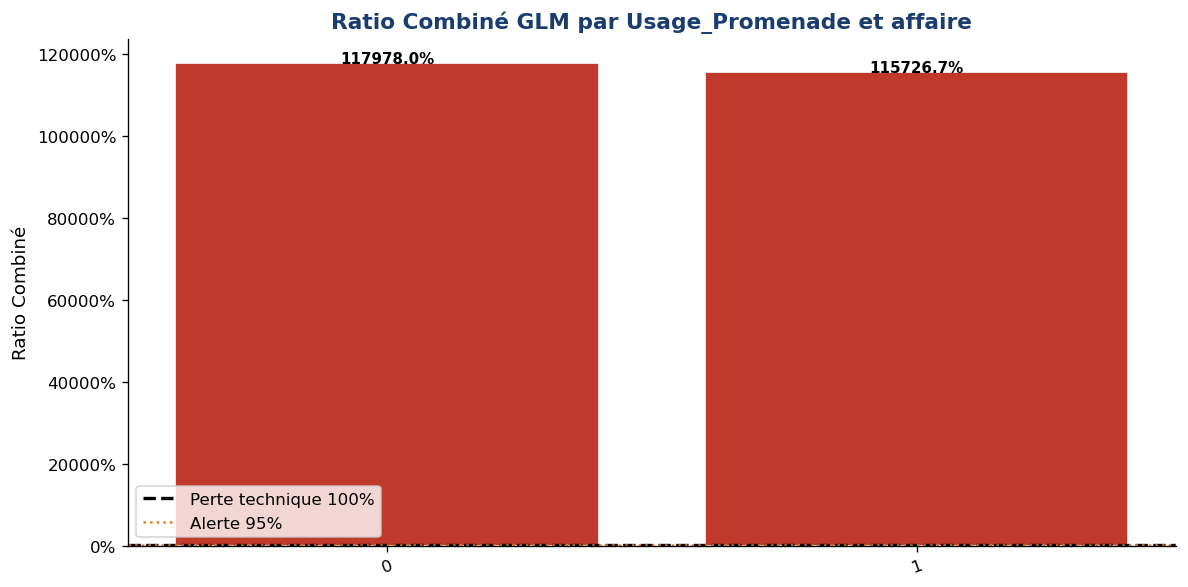

✅ fig_32_ratio_combine_glm.png


In [33]:
if glm_freq and glm_sev and col_primes and segs_disponibles:
    df_freq_pred['primes']    = df_freq[col_primes].values
    df_freq_pred['sinistres_pred'] = df_freq_pred['prime_pure'] * (
        df_freq_pred[col_expo].values if col_expo in df_freq_pred.columns
        else 1)

    seg = segs_disponibles[0]
    rc_seg = df_freq_pred.groupby(seg).apply(
        lambda g: (g['sinistres_pred'].sum() + RATIO_FRAIS * g['primes'].sum()) / g['primes'].sum()
        if g['primes'].sum() > 0 else np.nan
    ).dropna().sort_values(ascending=False)

    print(f'=== Ratio Combiné GLM par {seg} ===')
    for seg_val, rc in rc_seg.items():
        flag = '🔴 PERTE' if rc > 1.0 else ('🟡 ALERTE' if rc > 0.95 else '🟢 OK')
        print(f'  {str(seg_val):<20} : {rc*100:6.1f}%  {flag}')

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [C3 if rc > 1.0 else (C4 if rc > 0.95 else C2) for rc in rc_seg.values]
    bars = ax.bar(rc_seg.index.astype(str), rc_seg.values, color=colors, edgecolor='white')
    ax.axhline(1.0, color='black', lw=2, ls='--', label='Perte technique 100%')
    ax.axhline(0.95, color=C4, lw=1.5, ls=':', label='Alerte 95%')
    for bar, val in zip(bars, rc_seg.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Ratio Combiné GLM par {seg}', fontweight='bold', color=C1)
    ax.set_ylabel('Ratio Combiné')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y*100:.0f}%'))
    ax.tick_params(axis='x', rotation=20)
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_32_ratio_combine_glm.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ fig_32_ratio_combine_glm.png')
else:
    print('⚠️ Données insuffisantes pour le ratio combiné par segment')

## 7. Courbe de Lorenz Actuarielle et Coefficient de Gini

La **courbe de Lorenz actuarielle** mesure le pouvoir discriminant du modèle de tarification.  
Elle compare la **distribution cumulée des sinistres observés** avec la **distribution cumulée
des primes prédites** (polices triées par prime croissante).  

$$\text{Gini} = 2 \times \text{AUC}_{\text{Lorenz}} - 1$$

**Interprétation :**
- Gini = 0 → modèle aléatoire (pas de discrimination)
- Gini = 1 → modèle parfait (tous les sinistres concentrés sur les assurés les plus risqués)
- En pratique, un bon GLM atteint Gini ≈ 0.25–0.45 en assurance automobile

> *Référence : Frees, Meyers & Cummings (2014), Predictive Modeling Applications in Actuarial Science*

In [34]:
def lorenz_gini(y_true, y_score, weights=None):
    """Calcule la courbe de Lorenz actuarielle et le coefficient de Gini.
    y_true  : sinistres observés
    y_score : prime prédite (score de risque)
    weights : exposition (optionnel)
    """
    df_lor = pd.DataFrame({'y': y_true, 'score': y_score})
    if weights is not None:
        df_lor['w'] = weights
    else:
        df_lor['w'] = 1.0
    df_lor = df_lor.dropna().sort_values('score')

    cum_w = np.cumsum(df_lor['w']) / df_lor['w'].sum()
    cum_s = np.cumsum(df_lor['y'] * df_lor['w']) / (df_lor['y'] * df_lor['w']).sum()

    # AUC par trapèze
    auc = np.trapz(cum_s, cum_w)
    gini = 2 * auc - 1
    return cum_w.values, cum_s.values, gini

print('✅ Fonction lorenz_gini définie')

✅ Fonction lorenz_gini définie


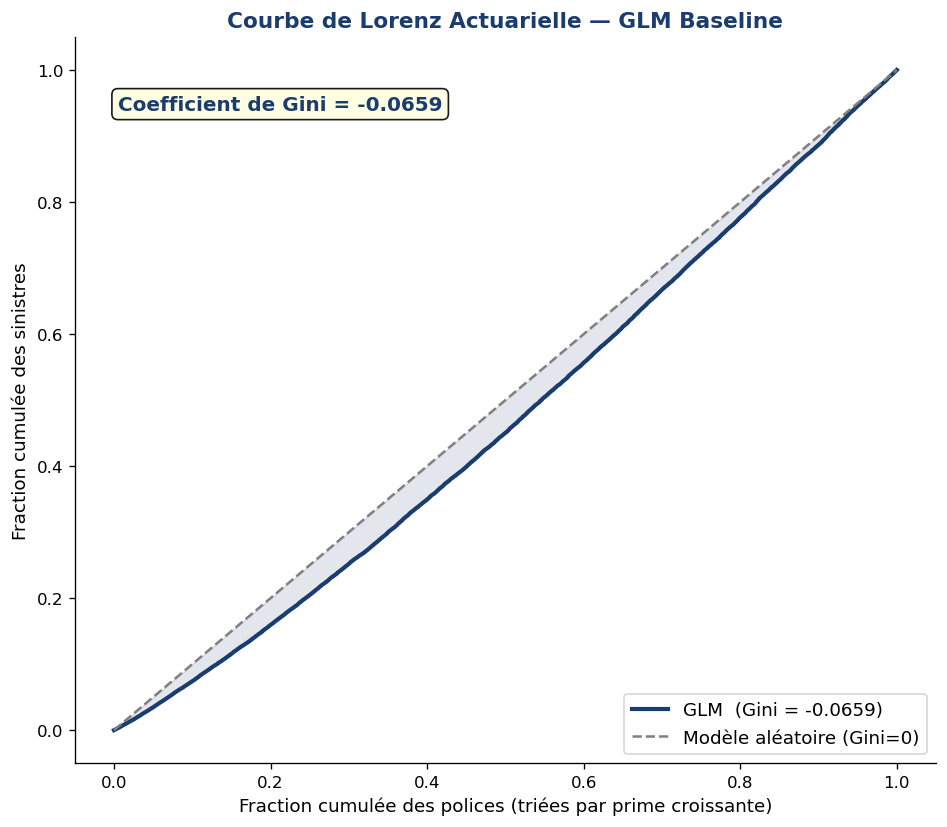

✅ fig_32_lorenz_glm.png | Gini GLM = -0.0659


In [35]:
if glm_freq and col_nb and col_expo:
    y_obs  = df_glm[col_nb].values
    y_scr  = df_freq_pred['prime_pure'].values[:len(y_obs)]
    w_expo = df_glm[col_expo].values if col_expo in df_glm.columns else None

    cum_w_glm, cum_s_glm, gini_glm = lorenz_gini(y_obs, y_scr, w_expo)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(cum_w_glm, cum_s_glm, color=C1, lw=2.5, label=f'GLM  (Gini = {gini_glm:.4f})')
    ax.plot([0, 1], [0, 1], color='grey', lw=1.5, ls='--', label='Modèle aléatoire (Gini=0)')
    ax.fill_between(cum_w_glm, cum_s_glm, cum_w_glm, alpha=0.12, color=C1)
    ax.set_xlabel('Fraction cumulée des polices (triées par prime croissante)', fontsize=11)
    ax.set_ylabel('Fraction cumulée des sinistres', fontsize=11)
    ax.set_title('Courbe de Lorenz Actuarielle — GLM Baseline', fontweight='bold', color=C1, fontsize=13)
    ax.legend(fontsize=11)
    ax.text(0.05, 0.90, f'Coefficient de Gini = {gini_glm:.4f}',
            transform=ax.transAxes, fontsize=12, fontweight='bold', color=C1,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    plt.tight_layout()
    plt.savefig('fig_32_lorenz_glm.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f'✅ fig_32_lorenz_glm.png | Gini GLM = {gini_glm:.4f}')
else:
    gini_glm = None
    print('⚠️ Courbe de Lorenz non calculable — colonnes manquantes')

## 8. Tableau Récapitulatif des Métriques GLM

Ce tableau est le **référentiel benchmark** que les Notebooks 3.3 (XGBoost) et 3.5 (CANN)  
devront battre pour justifier l'usage de méthodes plus complexes.

In [36]:
metrics_glm = {'Modèle': 'GLM Baseline'}

if glm_freq:
    metrics_glm['AIC (fréquence)'] = round(glm_freq.aic, 2)
    metrics_glm['Ratio déviance/df (fréquence)'] = round(glm_freq.deviance/glm_freq.df_resid, 3)

if glm_sev:
    metrics_glm['AIC (sévérité)'] = round(glm_sev.aic, 2)
    metrics_glm['RMSE sévérité (DT)'] = round(rmse_sev, 2)
    metrics_glm['R² sévérité'] = round(r2_sev, 4)

if gini_glm:
    metrics_glm['Gini actuariel'] = round(gini_glm, 4)

df_metrics = pd.DataFrame([metrics_glm]).set_index('Modèle')
df_metrics.to_csv('benchmark_module_32_glm.csv')

print('=== MÉTRIQUES GLM BASELINE — RÉFÉRENCE BENCHMARK ACTUWISE ===')
print(df_metrics.T.to_string())
print('\n✅ Exporté → benchmark_module_32_glm.csv')
print('   Ce fichier sera complété par XGBoost (3.3) et CANN (3.5)')

=== MÉTRIQUES GLM BASELINE — RÉFÉRENCE BENCHMARK ACTUWISE ===
Modèle                         GLM Baseline
AIC (fréquence)                 356915.3100
Ratio déviance/df (fréquence)        2.5190
AIC (sévérité)                  667558.3200
RMSE sévérité (DT)                3327.8400
R² sévérité                          0.0038
Gini actuariel                      -0.0659

✅ Exporté → benchmark_module_32_glm.csv
   Ce fichier sera complété par XGBoost (3.3) et CANN (3.5)


In [37]:
# ── Export prime pure par assuré → utilisée en 3.3, 3.5, 3.6 ────────
if glm_freq and glm_sev:
    df_output = df_freq_pred[['lambda_hat', 'mu_hat', 'prime_pure']].copy()
    df_output.index = df_glm.index  # réaligner avec l'index original
    df_output.to_csv('prime_pure_glm.csv', index=True)
    print(f'✅ prime_pure_glm.csv exporté ({len(df_output):,} lignes)')
    print('   → Ce fichier sera utilisé comme offset CANN dans le Notebook 3.5')

✅ prime_pure_glm.csv exporté (94,846 lignes)
   → Ce fichier sera utilisé comme offset CANN dans le Notebook 3.5


## 9. Insights Métier — GLM Baseline


In [38]:
print('=' * 65)
print('  ACTUWISE — Module 3.2 : INSIGHTS MÉTIER GLM')
print('=' * 65)

print('\n📊 MODÈLE FRÉQUENCE (Poisson)')
if glm_freq:
    sig_vars = glm_freq.pvalues[glm_freq.pvalues < 0.05].drop('Intercept', errors='ignore')
    print(f'   Variables significatives (p<0.05) : {len(sig_vars)}')
    if len(sig_vars):
        top_pos = glm_freq.params.drop('Intercept',errors='ignore').nlargest(3)
        top_neg = glm_freq.params.drop('Intercept',errors='ignore').nsmallest(3)
        print(f'   Top 3 facteurs AGGRAVANTS  : {list(top_pos.index)}')
        print(f'   Top 3 facteurs PROTECTEURS : {list(top_neg.index)}')
    print(f'   Ratio dispersion           : {glm_freq.deviance/glm_freq.df_resid:.3f}')

print('\n💰 MODÈLE SÉVÉRITÉ (Gamma)')
if glm_sev:
    sig_sev = glm_sev.pvalues[glm_sev.pvalues < 0.05].drop('Intercept', errors='ignore')
    print(f'   Variables significatives (p<0.05) : {len(sig_sev)}')
    print(f'   RMSE sévérité              : {rmse_sev:,.0f} DT')
    print(f'   R²  sévérité               : {r2_sev:.4f}')

print('\n🎯 PRIME PURE')
if glm_freq and glm_sev:
    pp = df_freq_pred['prime_pure']
    print(f'   Prime pure moyenne         : {pp.mean():.2f} DT / année-véhicule')
    print(f'   Écart-type                 : {pp.std():.2f} DT')
    print(f'   Rapport max/min (P99/P1)   : {pp.quantile(.99)/pp.quantile(.01):.1f}x')
    print(f'   → Un assuré P99 paie {pp.quantile(.99)/pp.quantile(.01):.1f}x plus que P1')

print('\n📈 POUVOIR DISCRIMINANT')
if gini_glm:
    print(f'   Gini GLM                   : {gini_glm:.4f}')
    if gini_glm < 0.20:
        print('   🟡 Pouvoir discriminant faible → ML apportera gain significatif')
    elif gini_glm < 0.35:
        print('   🟢 Pouvoir discriminant modéré → ML apportera amélioration marginale')
    else:
        print('   ✅ Bon pouvoir discriminant — GLM déjà performant')

print('\n' + '=' * 65)
print('→ Livrables pour Notebook 3.3 (XGBoost) :')
print('  • prime_pure_glm.csv         — primes GLM à battre')
print('  • benchmark_module_32_glm.csv — métriques référence')
print('  • Gini GLM                   — seuil à dépasser')
print('=' * 65)

  ACTUWISE — Module 3.2 : INSIGHTS MÉTIER GLM

📊 MODÈLE FRÉQUENCE (Poisson)
   Variables significatives (p<0.05) : 2
   Top 3 facteurs AGGRAVANTS  : ['age_conducteur', 'anciennete_vehicule']
   Top 3 facteurs PROTECTEURS : ['anciennete_vehicule', 'age_conducteur']
   Ratio dispersion           : 2.519

💰 MODÈLE SÉVÉRITÉ (Gamma)
   Variables significatives (p<0.05) : 2
   RMSE sévérité              : 3,328 DT
   R²  sévérité               : 0.0038

🎯 PRIME PURE
   Prime pure moyenne         : 1205.42 DT / année-véhicule
   Écart-type                 : 751.64 DT
   Rapport max/min (P99/P1)   : 120.0x
   → Un assuré P99 paie 120.0x plus que P1

📈 POUVOIR DISCRIMINANT
   Gini GLM                   : -0.0659
   🟡 Pouvoir discriminant faible → ML apportera gain significatif

→ Livrables pour Notebook 3.3 (XGBoost) :
  • prime_pure_glm.csv         — primes GLM à battre
  • benchmark_module_32_glm.csv — métriques référence
  • Gini GLM                   — seuil à dépasser


In [39]:
# ── Sauvegarde des modèles GLM ────────────────────────────────────────
import joblib, os

os.makedirs('models', exist_ok=True)

if glm_freq:
    joblib.dump(glm_freq, 'models/glm_freq.pkl')
    print('✅ models/glm_freq.pkl sauvegardé')

if glm_sev:
    joblib.dump(glm_sev, 'models/glm_sev.pkl')
    print('✅ models/glm_sev.pkl sauvegardé')

# Téléchargement (Kaggle / Jupyter)
try:
    from IPython.display import FileLink, display
    display(FileLink('models/glm_freq.pkl'))
    display(FileLink('models/glm_sev.pkl'))
except:
    print('→ Télécharge depuis : models/glm_freq.pkl | models/glm_sev.pkl')

✅ models/glm_freq.pkl sauvegardé
✅ models/glm_sev.pkl sauvegardé


c:\Users\LENOVO\Desktop\Actuariat\Module3\models\glm_freq.pkl

c:\Users\LENOVO\Desktop\Actuariat\Module3\models\glm_sev.pkl

## 10. Livrables pour le Notebook 3.3

| Fichier | Contenu | Utilisé dans |
|---------|---------|------|
| `prime_pure_glm.csv` | Prime pure par assuré (GLM) | Notebook 3.3, 3.5, 3.6 |
| `benchmark_module_32_glm.csv` | Métriques GLM (AIC, RMSE, R², Gini) | Notebook 3.6 |
| `fig_32_lorenz_glm.png` | Courbe de Lorenz GLM | Notebook 3.6 (comparaison) |

**Ce que le Notebook 3.3 va faire :**
- Entraîner XGBoost fréquence (classification binaire) + XGBoost sévérité (régression log)
- Comparer Gini XGBoost vs Gini GLM sur la même courbe de Lorenz
- Validation temporelle out-of-time : train 2018–2021 | test 2022–2023

---
*ACTUWISE — Notebook 3.2 terminé ✅*